In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import PIL 
import scipy.io
import cv2
import os
import scipy as sp

In [57]:
# All the path 
projet_path = os.getcwd()
image_path = os.path.join(projet_path, "Lame_criblee")
mask_path = os.path.join(projet_path, "Terrain")

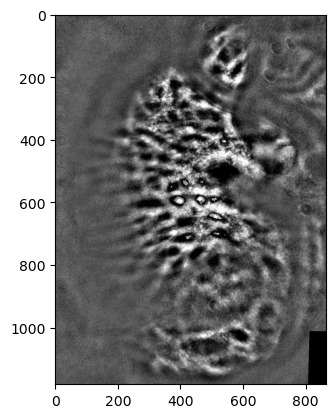

In [58]:
im_name = "LC001"
if os.path.exists(os.path.join(image_path, f"{im_name}.jpg")): 
    im = cv2.imread(f'{image_path}/{im_name}.jpg')
elif os.path.exists(os.path.join(image_path, f"{im_name}.png")):
    im = cv2.imread(f'{image_path}/{im_name}.png')
else : 
    print("The file path does not exist")
[H, W, I] = im.shape
plt.imshow(im)
im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

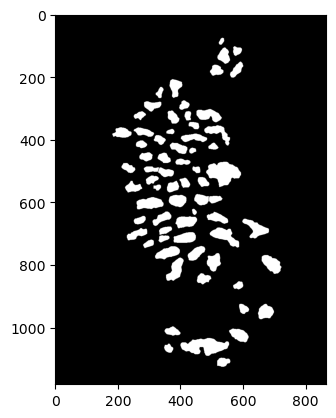

In [59]:
# Charger le .mat
mat = scipy.io.loadmat(f'Terrain/{im_name}_VT.mat')
# Récupérer juste la matrice et la mettre dnas la varibale mask (car binaire)
mask = mat['seeds']
plt.imshow(mask, cmap=plt.cm.gray)

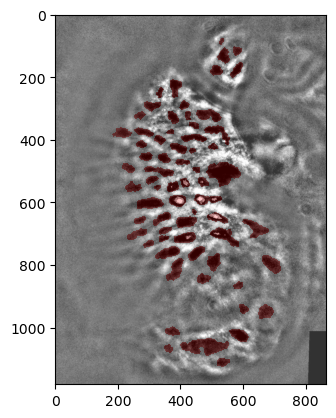

In [60]:
# Overlap image and mask
colormap = colors.ListedColormap(['white', 'red'])
plt.imshow(im, cmap=plt.cm.gray)
plt.imshow(mask, cmap = colormap, alpha = 0.2)

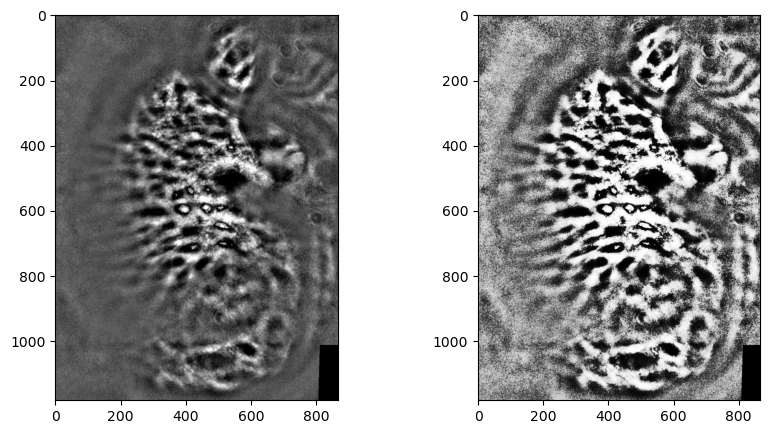

In [61]:
# Egalisation de l'histogramme de niveaux de gris
egal_image = cv2.equalizeHist(im)    
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(im, cmap = plt.cm.gray)
axes[1].imshow(egal_image, cmap = plt.cm.gray)

1182 867


IndexError: index 867 is out of bounds for axis 1 with size 867

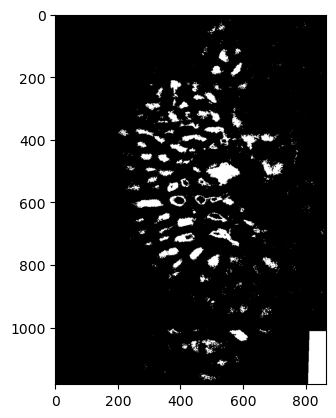

In [62]:
# Cleaning the black squares
_, thresholded_im = cv2.threshold(egal_image, 10, 122, cv2.THRESH_BINARY_INV)
plt.imshow(thresholded_im, cmap=plt.cm.gray)

[H, W] = egal_image.shape
print(H,W)
cleaned_im = egal_image.copy()
for i in range(H):
    for j in range (W):
        if i==0 or j==0 or i==H or j==W:
            if egal_image[i,j]==0:
                cleaned_im[i,j]=120
        elif egal_image[i,j]==0 and (egal_image[i-1,j-1]==0 or egal_image[i+1,j+1]==0 or egal_image[i+1,j-1]==0 or egal_image[i-1,j+1]==0):
            cleaned_im[i,j]=120

plt.imshow(cleaned_im, cmap = plt.cm.gray)


In [63]:
hist = cv2.calcHist([im], [0], None, [256], [0,256])
egal_hist = cv2.calcHist([egal_image], [0], None, [256], [0,256])
print(np.mean(hist))
print(np.mean(egal_hist))
print(np.median(hist))
print(np.median(egal_hist))
print(np.var(hist))
print(np.var(egal_hist))

4003.1016
4003.1016
1591.5
2204.0
28683536.0
30796102.0


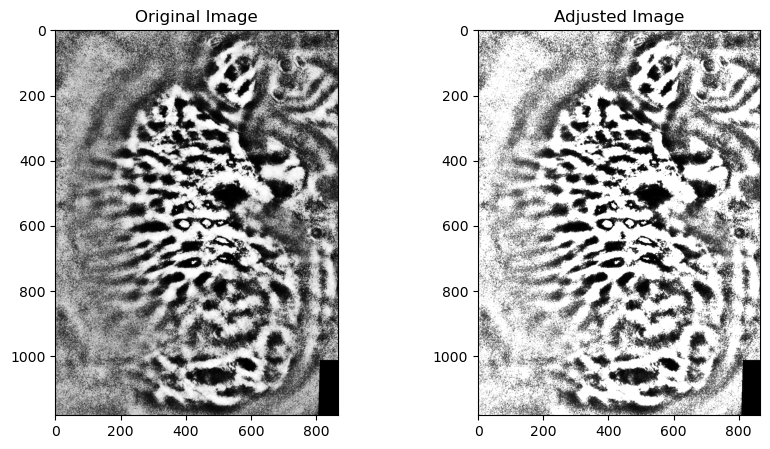

In [64]:
im = egal_image
contrast_coeff = 1.6
brightness_coeff = 0 #coeff entre 1 et 3 (en dessous de 1, diminue le contrast)
brighter_image = im*contrast_coeff+brightness_coeff
brighter_image = np.clip(brighter_image, 0, 255)  # Limit values to the range [0, 255]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(egal_image, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(brighter_image, cmap='gray')
axes[1].set_title('Adjusted Image')
plt.show()

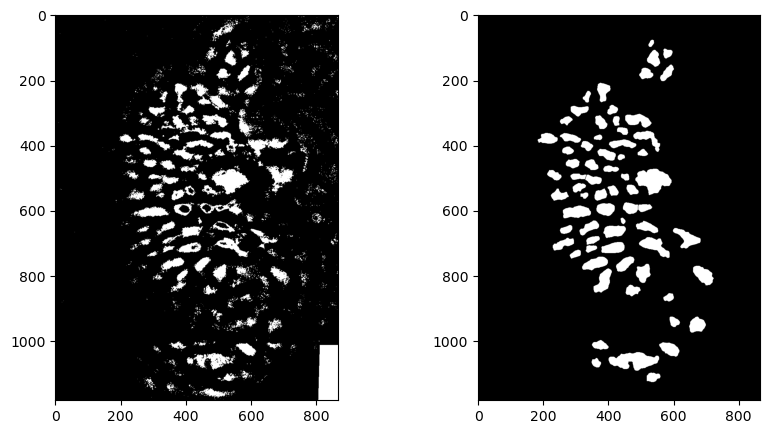

In [65]:
# Put a threshold on the image 
ret1, seuil_im1 = cv2.threshold(brighter_image, 35, 255, cv2.THRESH_BINARY_INV)
ret2, seuil_im2 = cv2.threshold(brighter_image, 30, 255, cv2.THRESH_BINARY_INV)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(seuil_im1, cmap = plt.cm.gray)
axes[1].imshow(mask, cmap = plt.cm.gray)

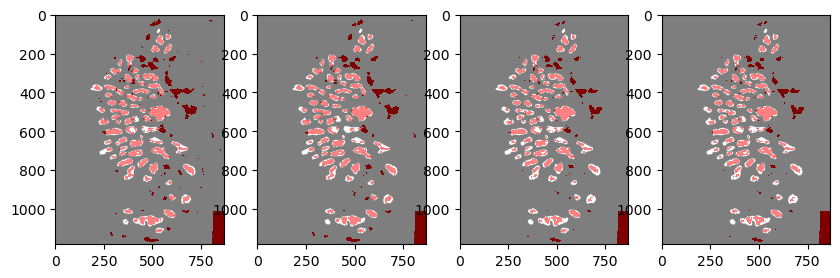

In [79]:
# Fill the missing spots inside the white structures
SE3 = np.ones((3,3),np.uint8)
SE5 = np.ones((5,5),np.uint8)
SE7 = np.ones((7,7),np.uint8)
SE9 = np.ones((9,9),np.uint8)
closing1 = cv2.morphologyEx(seuil_im1, cv2.MORPH_CLOSE, SE3)
opening1 = cv2.morphologyEx(closing1, cv2.MORPH_OPEN, SE5)
closing2 = cv2.morphologyEx(seuil_im1, cv2.MORPH_CLOSE, SE3)
opening2 = cv2.morphologyEx(closing2, cv2.MORPH_OPEN, SE7)
opening3 = cv2.morphologyEx(seuil_im1, cv2.MORPH_OPEN, SE5)
closing3 = cv2.morphologyEx(opening3, cv2.MORPH_CLOSE, SE9)
opening4 = cv2.morphologyEx(seuil_im1, cv2.MORPH_OPEN, SE5)
closing4 = cv2.morphologyEx(opening4, cv2.MORPH_CLOSE, SE7)
fig, axes = plt.subplots(1, 4, figsize=(10, 5))
axes[0].imshow(mask, cmap = plt.cm.gray)
axes[0].imshow(opening1, cmap = colormap, alpha = 0.5)
axes[1].imshow(mask, cmap = plt.cm.gray)
axes[1].imshow(opening2, cmap = colormap, alpha = 0.5)
axes[2].imshow(mask, cmap = plt.cm.gray)
axes[2].imshow(opening3, cmap = colormap, alpha = 0.5)
axes[3].imshow(mask, cmap = plt.cm.gray)
axes[3].imshow(opening4, cmap = colormap, alpha = 0.5)

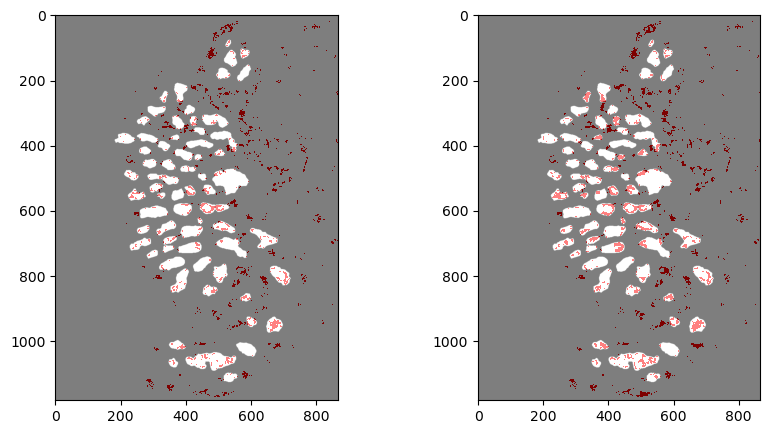

In [90]:
# Not working at all
tophat1 = cv2.morphologyEx(seuil_im1, cv2.MORPH_TOPHAT, SE7)
tophat2 = cv2.morphologyEx(seuil_im1, cv2.MORPH_TOPHAT, SE9)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mask, cmap = plt.cm.gray)
axes[0].imshow(tophat1, cmap = colormap, alpha = 0.5)
axes[1].imshow(mask, cmap = plt.cm.gray)
axes[1].imshow(tophat2, cmap = colormap, alpha = 0.5)

In [ ]:
# Put a threshold on the image with Otsu
ret2,th2 = cv2.threshold(egal_image,10,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(th2, cmap = plt.cm.gray)
axes[1].imshow(mask, cmap = plt.cm.gray)

In [ ]:
# Put a threshold on the image with an adaptative gaussian threhsold 
gauss_seuil_im = cv2.adaptiveThreshold(egal_image,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,15,2)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gauss_seuil_im, cmap = plt.cm.gray)
axes[1].imshow(mask, cmap = plt.cm.gray)

In [ ]:
# Put a threshold on the image with Otsu and a previous blur
blur = cv2.GaussianBlur(egal_image,(5,5),0)
ret3,th3 = cv2.threshold(blur,20,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(th3, cmap = plt.cm.gray)
axes[1].imshow(mask, cmap = plt.cm.gray)

In [ ]:
def imfilter(im,noyau):
    # Creation du bordage en miroir 
    h,w = np.shape(noyau)
    hbis = int(np.floor(h/2))
    wbis = int(np.floor(w/2))
    im_bis = np.pad(im, ((hbis,hbis),(wbis,wbis)),'symmetric')
    [Hbis,Wbis] = im_bis.shape
    # Delete le bordage 
    conv = sp.signal.convolve2d(im_bis, noyau)
    conv_bis = conv[hbis:Hbis-hbis, wbis:Wbis-wbis]
    return conv_bis

In [ ]:
# Filtre dérivatuer, passe haut, dessine les contours 
def passeHaut(im): 
    noyauhoriz = np.array([[-1, 0, 1]])
    noyauvert = np.array([[-1], [0], [1]])

    imhoriz = imfilter(im,noyauhoriz)
    imvert = imfilter(im,noyauvert)
    imcontour = np.sqrt(imhoriz**2 + imvert**2)

    fig, (ax1, ax4) = plt.subplots(2, 2)
    ax1.imshow(im, cmap=plt.cm.gray)
    ax2.imshow(imcontour, cmap=plt.cm.gray)

    return 
passeHaut(brighter_image)

In [ ]:
# Noyau Lapalcien ou noyau dérivateur, fait apparaitre les coutours 
def laplacien(im, nb_voisins):
    if nb_voisins == 4 : 
        m_laplacien = [[0, -1, 0],
                   [-1, 4, -1],
                   [0, -1, 0]]
    elif nb_voisins == 8 : 
        m_laplacien = [[-1, -1, -1],
                   [-1, 8, -1],
                   [-1, -1, -1]]
    else : 
        return 0
    filtered_im = im*m_laplacien
    return filtered_im